In [1]:
from distgen import Generator

from pmd_beamphysics import ParticleGroup
from pmd_beamphysics.interfaces.impact import parse_impact_particles, impact_particles_to_particle_data

import os

# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (12,4)

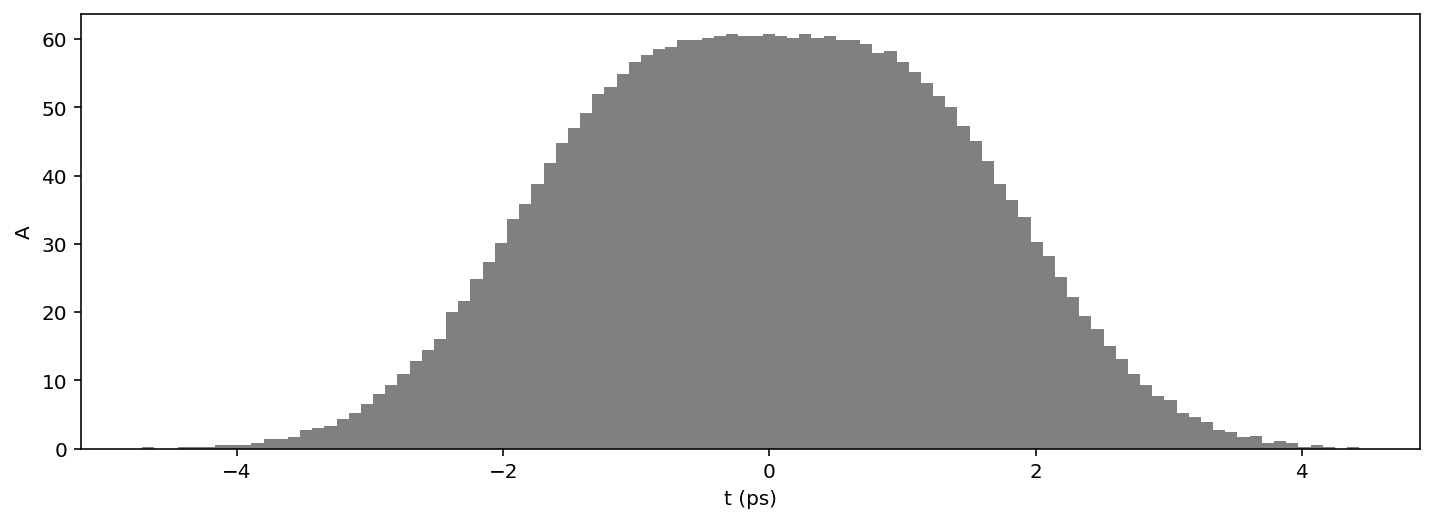

In [2]:
YAML="""
n_particle: 10000
random_type: hammersley

start:
  type: cathode
  MTE:
    value: 414
    units: meV    

total_charge:
  value: 250
  units: pC
    
r_dist:
  n_sigma_cutoff: 1.5
  sigma_xy:
    value: 0.4
    units: mm
  type: radial_gaussian

t_dist:
  type: superposition
  dists: 
    d1: 
      type: gaussian
      avg_t:
        units: ps
        value: 0
      sigma_t:
        units: ps
        value: 1
      n_sigma_cutoff: 5  
    d2: 
      type: gaussian
      avg_t:
        units: ps
        value: 2
      sigma_t:
        units: ps
        value: 1
      n_sigma_cutoff: 5
  

# Re-center
transforms:
  t1:
    avg_t:
      units: ps
      value:  0
    type: set_avg t
  
"""

G = Generator(YAML)
G.run()
P1 = G.particles
P1.plot('t')


# Compare

In [3]:
# Partcl.data
name2 = 'partcl.data'
pfile = os.path.join(os.environ['LCLS_LATTICE'], 'impact/models/cu_inj/partcl.data')
assert os.path.exists(pfile)

tout = parse_impact_particles(pfile, skiprows=1)
data = impact_particles_to_particle_data(tout, mc2=0.511e6, species='electron', macrocharge=0, cathode_kinetic_energy_ref=1.0, verbose=True )
P2 = ParticleGroup(data=data)

# Center
P2.t -= P2['mean_t']

Converting z to t according to cathode_kinetic_energy_ref = 1.0 eV


In [4]:
# Default yaml
# name2='distgen.yaml'
# G2 = Generator(name2)
# G2.run()
# P2 = G2.particles

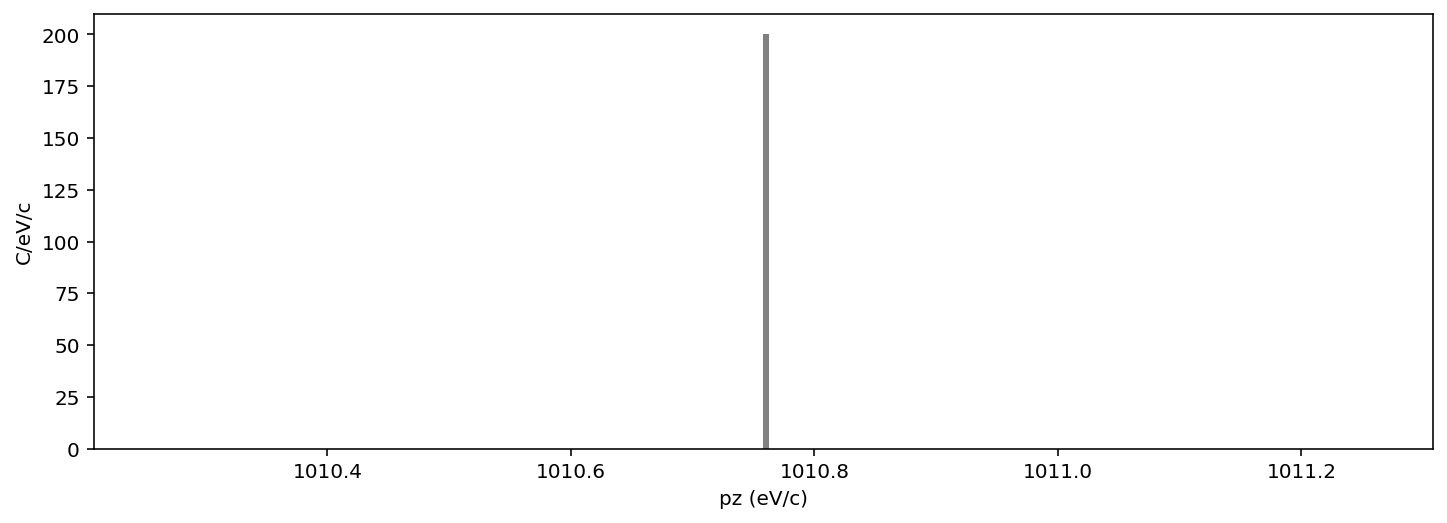

In [5]:
P2.plot('pz', bins=200)

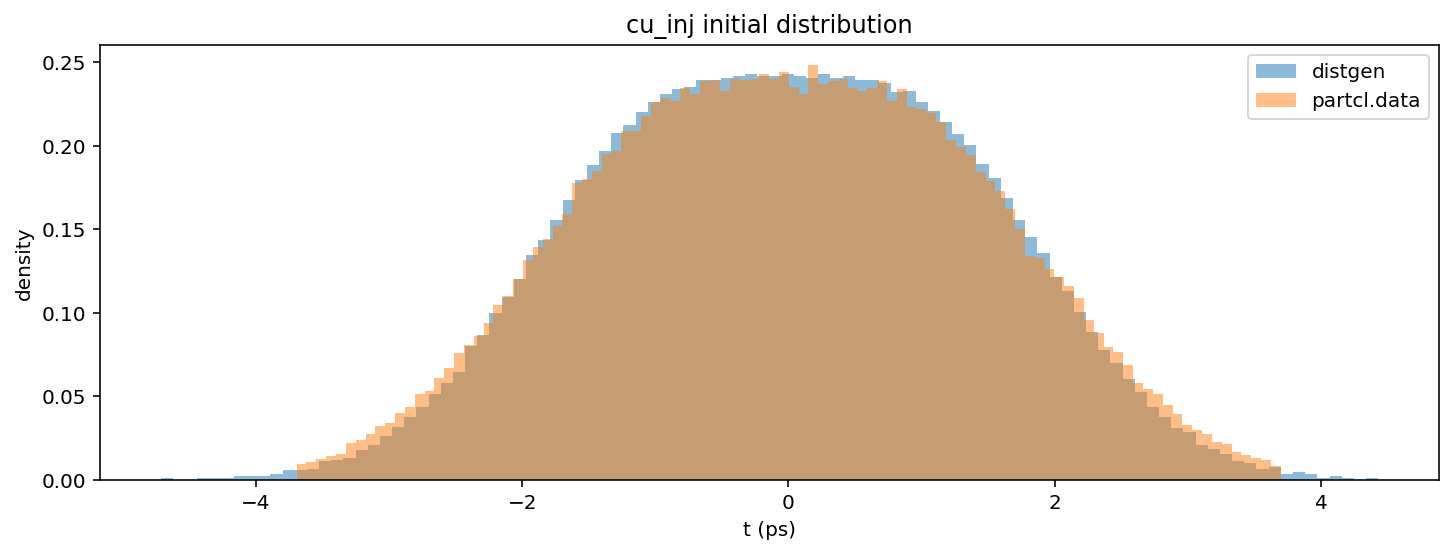

In [6]:
k = 't'
plt.hist(P1[k]*1e12, label='distgen', alpha = 0.5, density=True, bins=100)
plt.hist(P2[k]*1e12, label=name2, alpha=0.5, density=True, bins=100)

plt.title('cu_inj initial distribution')
plt.xlabel('t (ps)')
plt.ylabel('density')
plt.legend()
#plt.savefig('test.png')

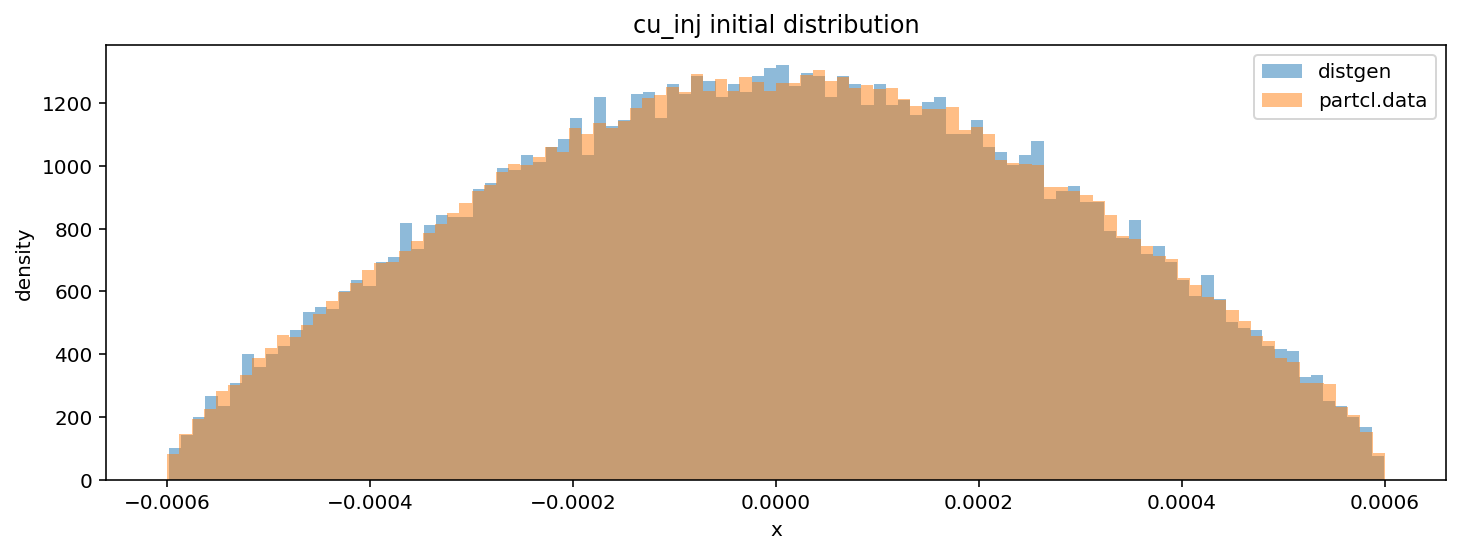

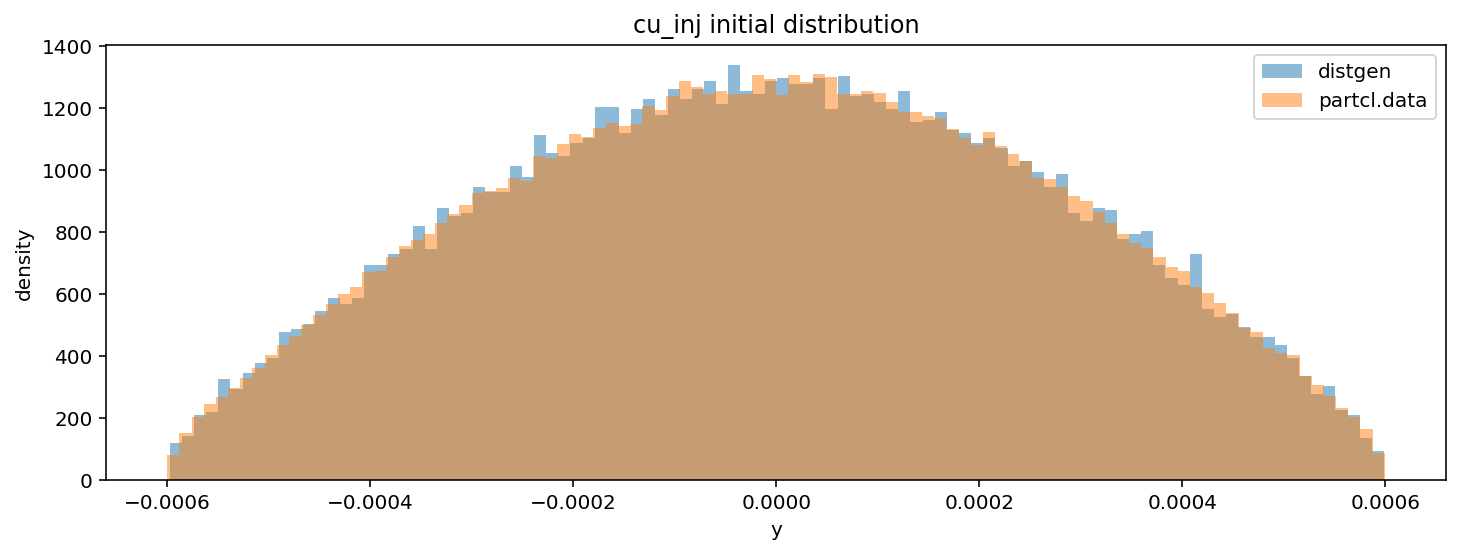

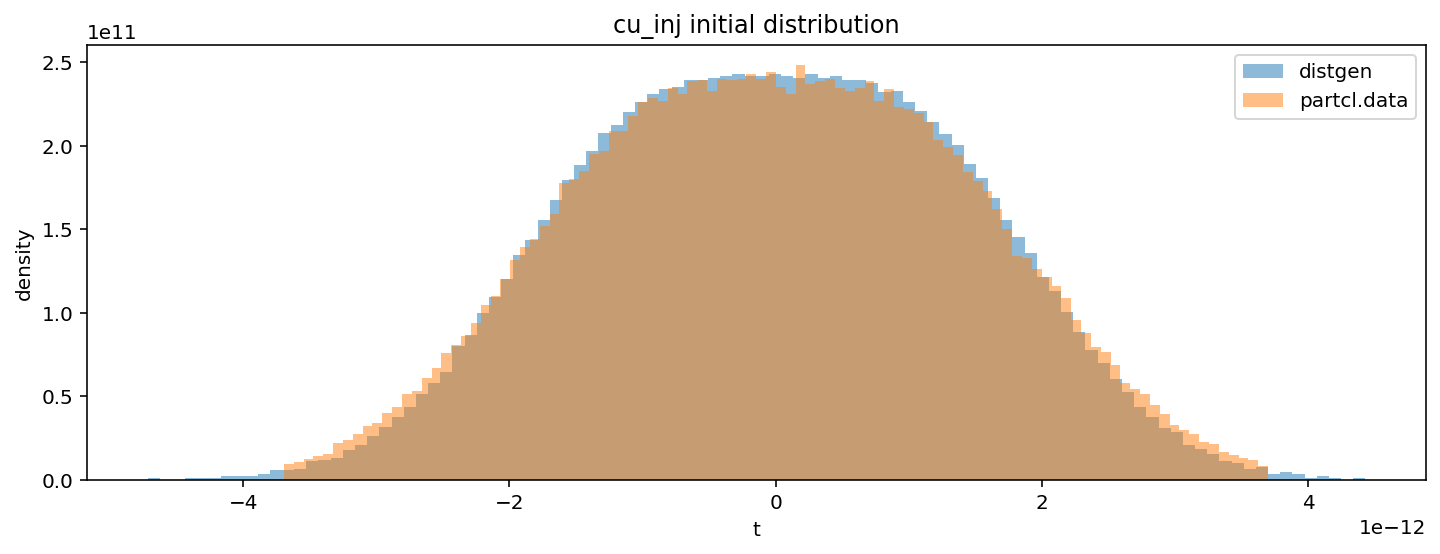

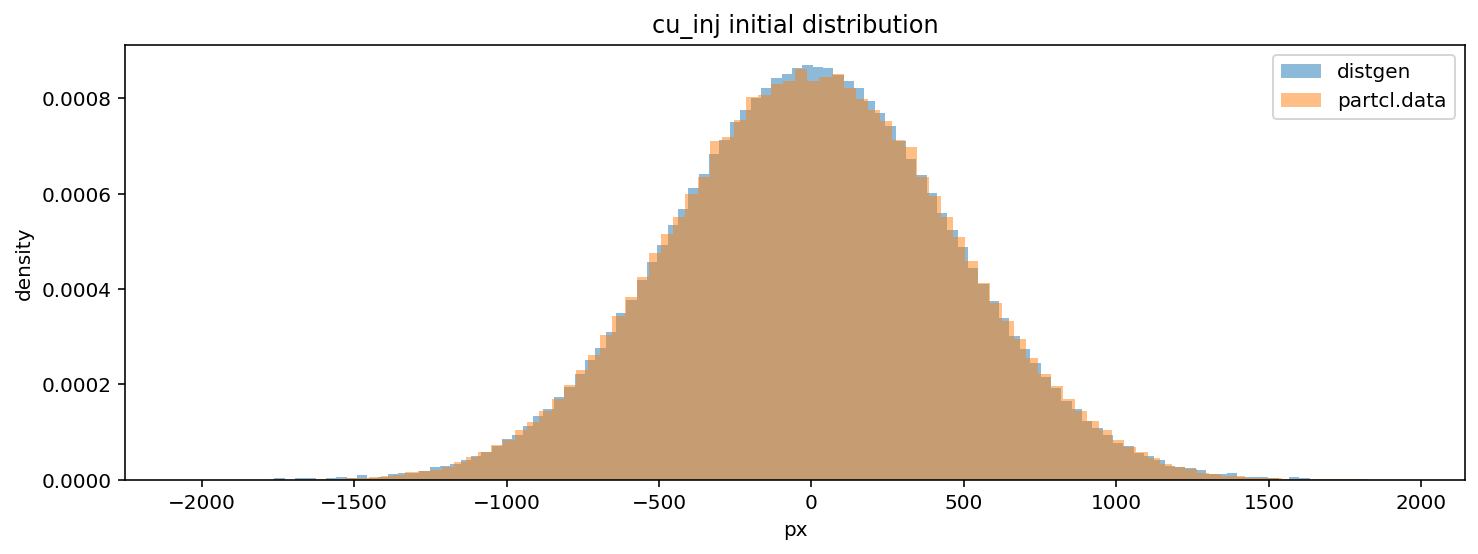

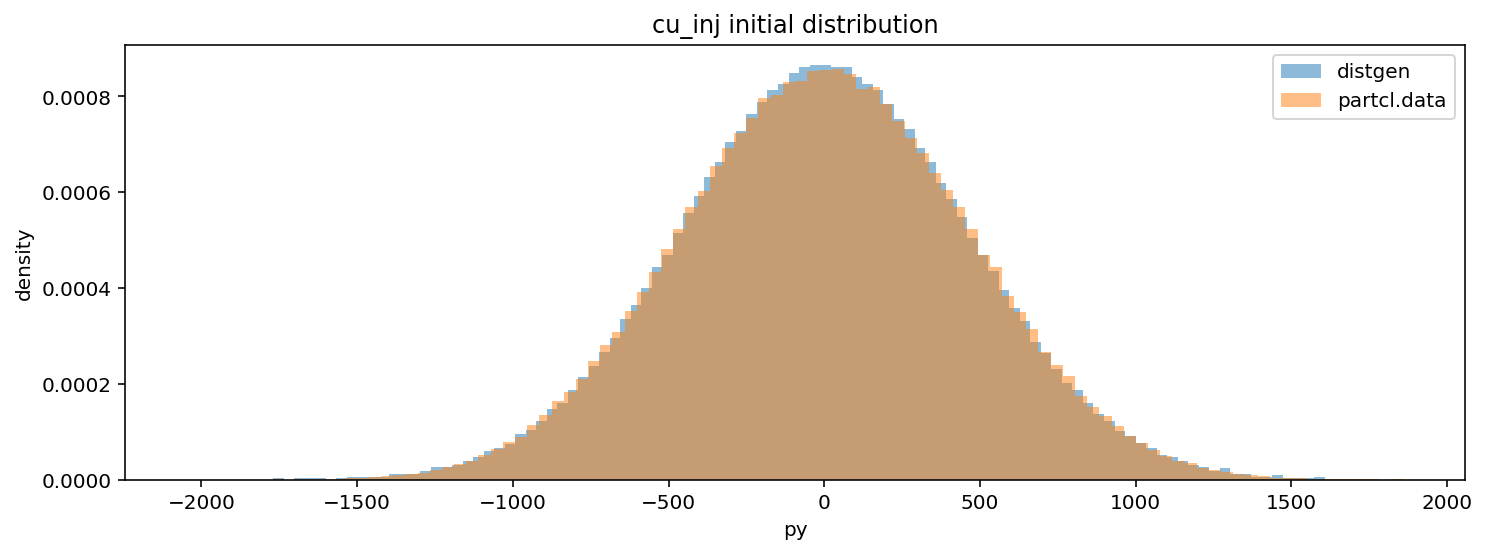

In [7]:
for k in ['x', 'y', 't', 'px', 'py']:
    plt.hist(P1[k], label='distgen', alpha = 0.5, density=True, bins=100)
    plt.hist(P2[k], label=name2, alpha=0.5, density=True, bins=100)
    
    plt.title('cu_inj initial distribution')
    plt.xlabel(k)
    plt.ylabel('density')
    plt.legend()
    plt.show()

# Flat 2 Gaussian

Two overlapping Gaussians with the same standard deviation $\sigma$ give a reasonably flat center when the offsets are $\pm \sigma$

Because the FWHM for a single Gaussian is $W_{1G}=2\sqrt{2\log2}\sigma$, this disribution has a FWHM of $W_{2G}=2(1+\sqrt{2\log2})\sigma$, or about $4.355\sigma$

The shortest LCLS copper injector single pulse is about 1 ps FWHM, so therefore the shortest pulse here is $W_{2G}=1.85$ ps


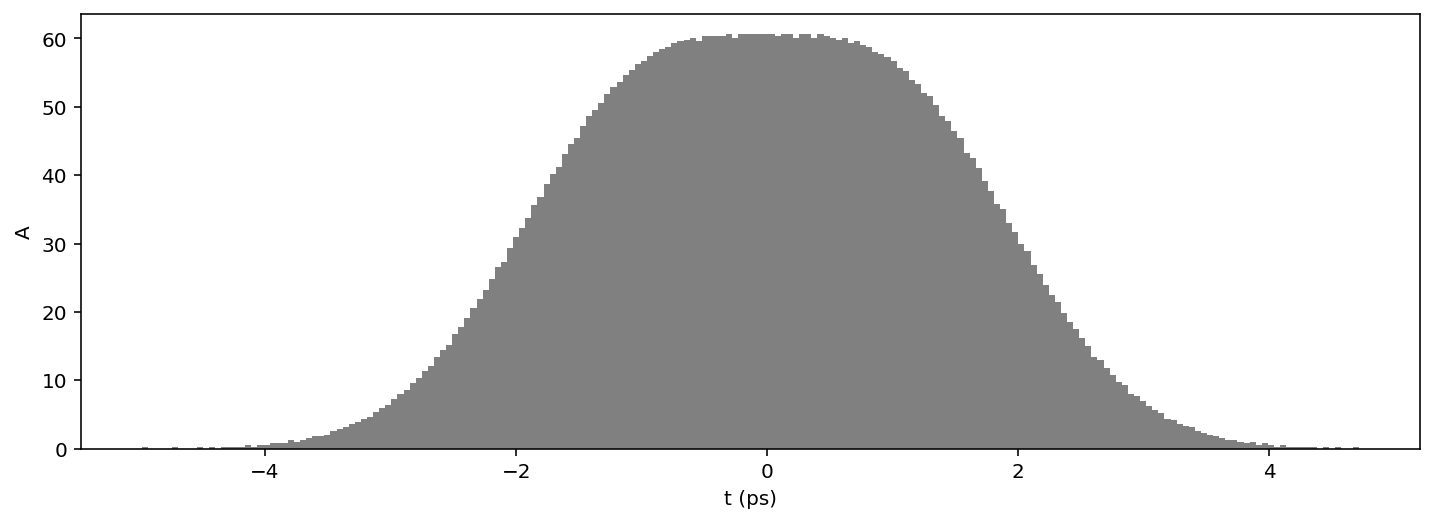

In [8]:
G2 = Generator(YAML)

sigma =1
offset = sigma
G2['n_particle'] = 20000
G2['t_dist:dists:d1:avg_t:value'] = -offset 
G2['t_dist:dists:d2:avg_t:value'] = offset 
G2['t_dist:dists:d1:sigma_t:value'] = sigma
G2['t_dist:dists:d2:sigma_t:value'] = sigma
G2.run()
P2 = G2.particles
P2.plot('t')

In [9]:
# Statistical sigma
P2['sigma_t']

1.4142083032026764e-12

# Tukey Approximation

The tukey distribution gives a reasonably good approximation to the Flat 2 Gaussian above when the tukey ratio is about 0.85 and the tukey length $l=7.2\sigma$.

This is the same as $l\approx3 W_{1G}$, and $l\approx  1.65 W_{2G}$.

Therefore the shortest tukey length in LCLS is about 3 ps.



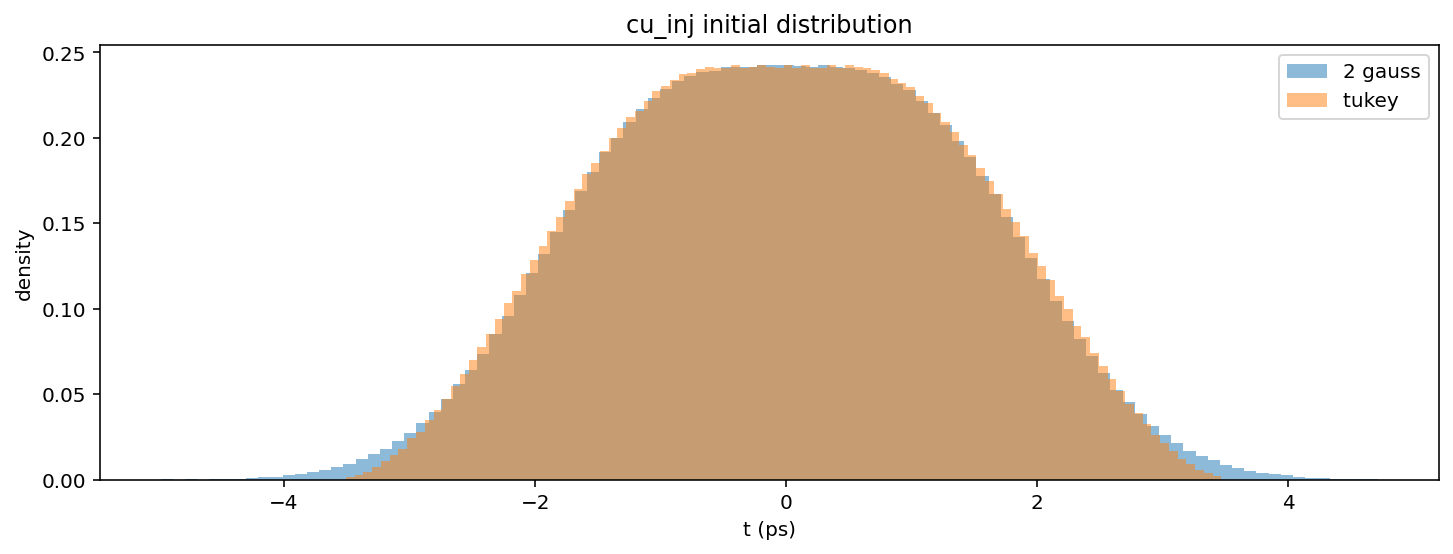

In [10]:
G3 = Generator('distgen.yaml')
G3['n_particle'] = 20000
G3['t_dist:length:value'] = 7.2
G3['t_dist:ratio:value'] = 0.85
G3.run()
P3 = G3.particles

k = 't'
plt.hist(P2[k]*1e12, label='2 gauss', alpha = 0.5, density=True, bins=100)
plt.hist(P3[k]*1e12, label='tukey ', alpha=0.5, density=True, bins=100)

plt.title('cu_inj initial distribution')
plt.xlabel('t (ps)')
plt.ylabel('density')
plt.legend()
#plt.savefig('test.png')

In [11]:
# Statistical sigma is a little shorter
P3['sigma_t']

1.3681147355740225e-12